In [ ]:
#Dataset: https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025
#George Rodriguez, Swati, Jorge Angon

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving blood_cell_anomaly_detection.csv to blood_cell_anomaly_detection (2).csv


In [ ]:
df = pd.read_csv("blood_cell_anomaly_detection.csv")

In [ ]:
print(df.shape)

(5880, 36)


In [ ]:
df

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CELL_003773,Platelet,0,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,...,81.4,34.2,CytoData,May_Grunwald_Giemsa,Olympus_BX51,40,360,0.1178,1.0000,0.8849
5876,CELL_005192,Target_Cell,1,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,...,88.1,34.4,Raabin_WBC,Giemsa,Zeiss_Axio,40,224,0.9034,0.9475,0.5928
5877,CELL_005227,Target_Cell,1,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,...,86.7,34.0,PBC_Dataset,Giemsa,Olympus_BX51,40,256,0.8493,0.6716,0.6381
5878,CELL_005391,Hypersegmented_Neutrophil,1,Infection,11.98,67.8,0.528,0.309,0.752,0.505,...,96.5,32.9,CytoData,Giemsa,Leica_DM2000,100,256,0.9004,0.6449,0.8801


In [ ]:
df = df.dropna()
print(df.shape)

(5880, 36)


In [ ]:
candidate_targets = ["cell_type", "disease_category", "anomaly_label", "target", "label", "class"]

In [ ]:
target_column = None
for col in candidate_targets:
    if col in df.columns:
        target_column = col
        break

In [ ]:
if target_column is None:
    raise ValueError(
        "Could not automatically find the target column. "
        "Please check df.columns and set target_column manually."
    )

In [ ]:
print(f"Target column selected: {target_column}")
print()

Target column selected: cell_type



In [ ]:
X = df.drop(columns=[target_column]).select_dtypes(include=[np.number]).copy()
y = df[target_column].copy()

if X.shape[1] == 0:
    raise ValueError("No numeric feature columns found. SVM requires numeric features.")

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Classes: {list(label_encoder.classes_)}")
print()

feature_names = X.columns.tolist()

Number of samples: 5880
Number of features: 28
Classes: ['Artefact', 'Basophil', 'Blast_Cell', 'Elliptocyte', 'Eosinophil', 'Hypersegmented_Neutrophil', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Normal_RBC', 'Platelet', 'Prolymphocyte', 'Reactive_Lymphocyte', 'Schistocyte', 'Sickle_Cell', 'Smudge_Cell', 'Spherocyte', 'Target_Cell', 'Toxic_Granulation']



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Training the SVM models...")
print()

Training the SVM models...



In [ ]:
# OvA = One-vs-All / One-vs-Rest
model_ova = OneVsRestClassifier(
    SVC(kernel='rbf', gamma='scale', C=1.0)
)

# OvO = One-vs-One
model_ovo = OneVsOneClassifier(
    SVC(kernel='rbf', gamma='scale', C=1.0)
)

In [ ]:
start_ova = time.time()
model_ova.fit(X_train_scaled, y_train)
time_ova = time.time() - start_ova

In [ ]:
start_ovo = time.time()
model_ovo.fit(X_train_scaled, y_train)
time_ovo = time.time() - start_ovo

In [ ]:
print("Training complete!")
print(f"OvA training time: {time_ova:.4f} seconds")
print(f"OvO training time: {time_ovo:.4f} seconds")
print()

Training complete!
OvA training time: 1.0456 seconds
OvO training time: 0.8253 seconds



In [ ]:
y_pred_ova = model_ova.predict(X_test_scaled)
y_pred_ovo = model_ovo.predict(X_test_scaled)

In [ ]:
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("=" * 70)
    print(f"{name} RESULTS")
    print("=" * 70)
    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()

    print("Classification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=[str(c) for c in label_encoder.classes_],
        zero_division=0
    ))
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(label_encoder.classes_))
    )
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    return accuracy, precision, recall, f1

OvA (One-vs-All) RESULTS
Accuracy : 96.66%
Precision: 0.9665
Recall   : 0.9666
F1-score : 0.9646

Classification Report:
                           precision    recall  f1-score   support

                 Artefact       1.00      0.92      0.96        24
                 Basophil       0.98      1.00      0.99        45
               Blast_Cell       0.73      0.90      0.81        84
              Elliptocyte       0.94      1.00      0.97        60
               Eosinophil       0.98      0.96      0.97        90
Hypersegmented_Neutrophil       1.00      1.00      1.00        48
               Lymphocyte       0.99      1.00      1.00       255
                 Monocyte       0.98      1.00      0.99       120
               Neutrophil       0.99      0.99      0.99       330
               Normal_RBC       1.00      1.00      1.00       270
                 Platelet       1.00      1.00      1.00        90
            Prolymphocyte       0.74      0.43      0.54        54
      R

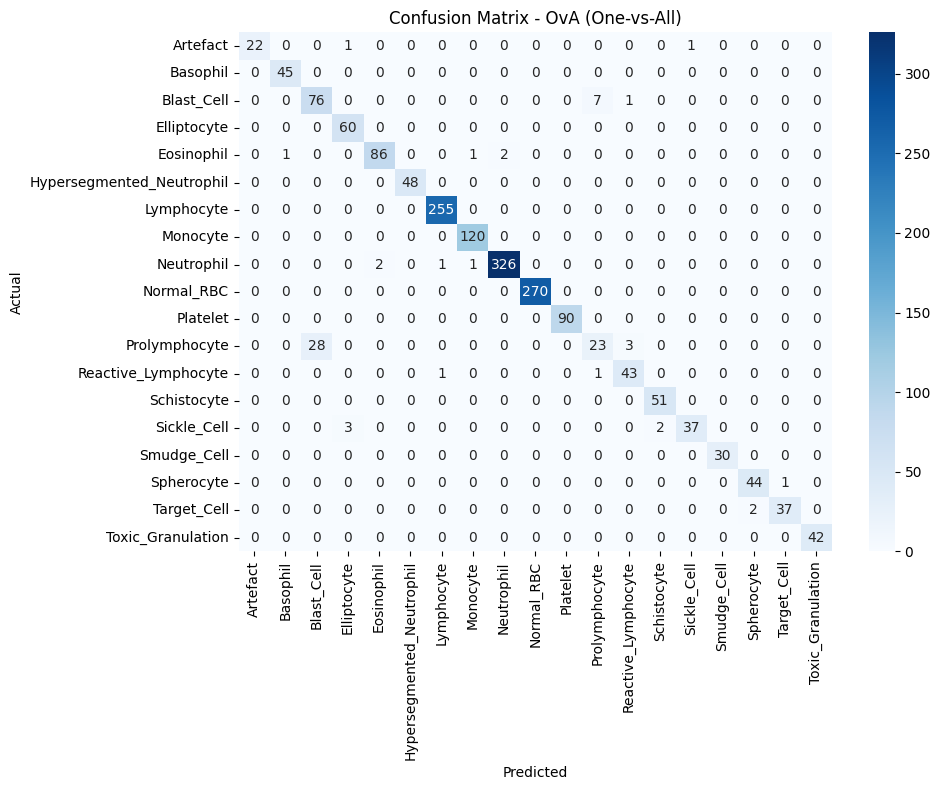

OvO (One-vs-One) RESULTS
Accuracy : 97.28%
Precision: 0.9724
Recall   : 0.9728
F1-score : 0.9721

Classification Report:
                           precision    recall  f1-score   support

                 Artefact       1.00      0.96      0.98        24
                 Basophil       0.98      1.00      0.99        45
               Blast_Cell       0.77      0.87      0.82        84
              Elliptocyte       0.95      0.98      0.97        60
               Eosinophil       0.99      0.97      0.98        90
Hypersegmented_Neutrophil       1.00      1.00      1.00        48
               Lymphocyte       1.00      1.00      1.00       255
                 Monocyte       1.00      1.00      1.00       120
               Neutrophil       0.99      1.00      1.00       330
               Normal_RBC       1.00      1.00      1.00       270
                 Platelet       1.00      1.00      1.00        90
            Prolymphocyte       0.71      0.56      0.62        54
      R

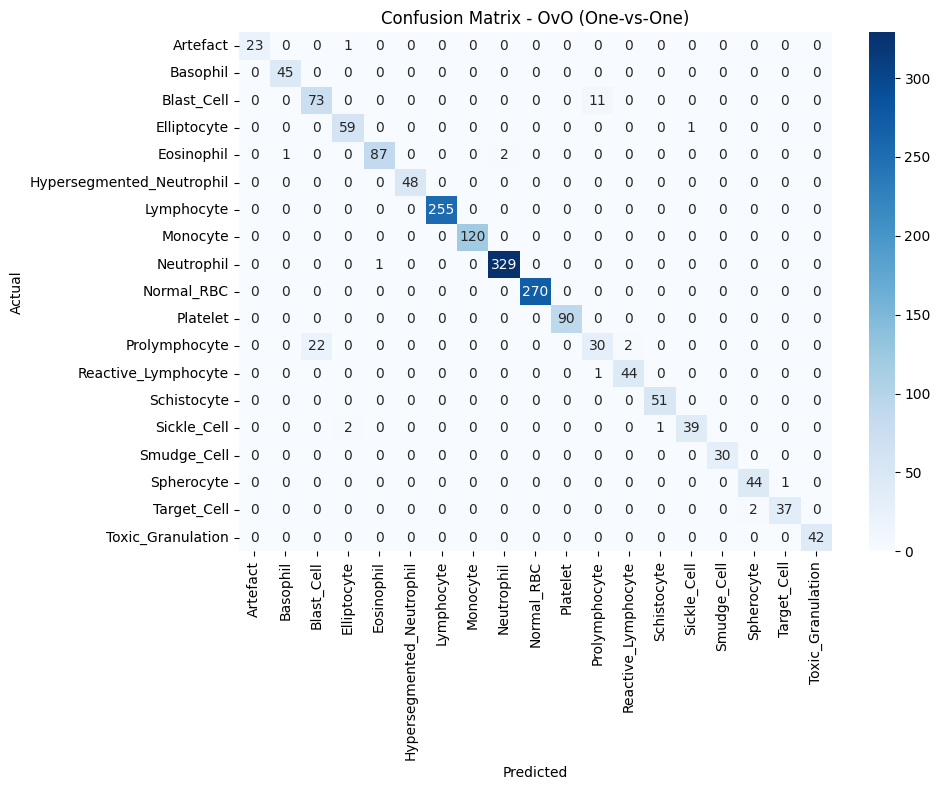

In [ ]:
acc_ova, prec_ova, rec_ova, f1_ova = evaluate_model("OvA (One-vs-All)", y_test, y_pred_ova)
acc_ovo, prec_ovo, rec_ovo, f1_ovo = evaluate_model("OvO (One-vs-One)", y_test, y_pred_ovo)

In [ ]:
X_scaled_all = scaler.fit_transform(X)

cv_scores_ova = cross_val_score(model_ova, X_scaled_all, y_encoded, cv=5, scoring="accuracy")
cv_scores_ovo = cross_val_score(model_ovo, X_scaled_all, y_encoded, cv=5, scoring="accuracy")

In [ ]:
print("OvA cross-validation accuracies:", cv_scores_ova)
print(f"OvA mean CV accuracy: {cv_scores_ova.mean() * 100:.2f}%")
print(f"OvA standard deviation: {cv_scores_ova.std():.4f}")
print()

print("OvO cross-validation accuracies:", cv_scores_ovo)
print(f"OvO mean CV accuracy: {cv_scores_ovo.mean() * 100:.2f}%")
print(f"OvO standard deviation: {cv_scores_ovo.std():.4f}")
print()

OvA cross-validation accuracies: [0.97193878 0.9702381  0.97959184 0.97789116 0.97363946]
OvA mean CV accuracy: 97.47%
OvA standard deviation: 0.0035

OvO cross-validation accuracies: [0.9787415  0.9744898  0.98469388 0.97704082 0.9787415 ]
OvO mean CV accuracy: 97.87%
OvO standard deviation: 0.0034



In [ ]:
print(f"{'Strategy':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Train Time'}")
print("-" * 90)
print(f"{'OvA':<20} {acc_ova*100:>7.2f}%     {prec_ova:>8.4f}    {rec_ova:>8.4f}    {f1_ova:>8.4f}    {time_ova:>8.4f}s")
print(f"{'OvO':<20} {acc_ovo*100:>7.2f}%     {prec_ovo:>8.4f}    {rec_ovo:>8.4f}    {f1_ovo:>8.4f}    {time_ovo:>8.4f}s")
print()

num_classes = len(label_encoder.classes_)
ova_classifiers = num_classes
ovo_classifiers = num_classes * (num_classes - 1) // 2

print(f"Number of classes: {num_classes}")
print(f"OvA classifiers needed: {ova_classifiers}")
print(f"OvO classifiers needed: {ovo_classifiers}")
print()

if acc_ovo > acc_ova:
    better_model = "OvO"
elif acc_ova > acc_ovo:
    better_model = "OvA"
else:
    better_model = "Tie"

print(f"Better accuracy: {better_model}")
print()

Strategy             Accuracy     Precision    Recall       F1           Train Time
------------------------------------------------------------------------------------------
OvA                    96.66%       0.9665      0.9666      0.9646      1.0456s
OvO                    97.28%       0.9724      0.9728      0.9721      0.8253s

Number of classes: 19
OvA classifiers needed: 19
OvO classifiers needed: 171

Better accuracy: OvO



In [ ]:
def predict_new_sample():
    print("=" * 70)
    print("NEW DATA ENTRY")
    print("=" * 70)
    print("Enter values for each feature to predict the class of a new sample.")
    print()

    new_values = []

    for feature in feature_names:
        while True:
            try:
                value = float(input(f"Enter {feature}: "))
                new_values.append(value)
                break
            except ValueError:
                print("Invalid input. Please enter a numeric value.")

    new_sample_df = pd.DataFrame([new_values], columns=feature_names)
    new_sample_scaled = scaler.transform(new_sample_df)

    pred_ova = model_ova.predict(new_sample_scaled)[0]
    pred_ovo = model_ovo.predict(new_sample_scaled)[0]

    class_ova = label_encoder.inverse_transform([pred_ova])[0]
    class_ovo = label_encoder.inverse_transform([pred_ovo])[0]

    print()
    print("Prediction Results:")
    print(f"OvA prediction: {class_ova}")
    print(f"OvO prediction: {class_ovo}")

predict_new_sample()

NEW DATA ENTRY
Enter values for each feature to predict the class of a new sample.

Enter anomaly_label: 1
Enter cell_diameter_um: 2
Enter nucleus_area_pct: 4
Enter chromatin_density: 1
Enter cytoplasm_ratio: 1.4
Enter circularity: 5
Enter eccentricity: 2
Enter granularity_score: 8
Enter lobularity_score: 10
Enter membrane_smoothness: 2
Enter cell_area_px: 55
Enter perimeter_px: 4
Enter mean_r: 21
Enter mean_g: 5
Enter mean_b: 1
Enter stain_intensity: 2
Enter wbc_count_per_ul: 5
Enter rbc_count_millions_per_ul: 3
Enter hemoglobin_g_dl: 2
Enter hematocrit_pct: 3
Enter platelet_count_per_ul: 4
Enter mcv_fl: 2
Enter mchc_g_dl: 3
Enter magnification_x: 4
Enter image_resolution_px: 2
Enter cytodiffusion_anomaly_score: 3
Enter cytodiffusion_classification_confidence: 4
Enter labeller_confidence_score: 2

Prediction Results:
OvA prediction: Blast_Cell
OvO prediction: Artefact


# Summary
This code builds a blood cell analysis system that learns from a dataset and then predicts what type of cell or anomaly a new sample may belong to. In simple terms, it cleans the data, automatically finds the column it needs to predict, uses the numeric measurements in the file to train two different versions of the same machine learning approach, and compares which one performs better. It checks how accurate and reliable each version is, shows where the models make correct or incorrect decisions, measures how long training takes, and then lets someone type in fresh sample values to get a prediction. Overall, the program is designed to help classify blood cell abnormalities in a structured, data-driven way while also comparing two strategies to see which gives the best results.